In [2]:
# =========================================================
# PROJETO DE VISUALIZAÇÃO DA INFORMAÇÃO
# Análise Estratégica de Vendas no E-commerce Brasileiro
# Autor: Matheus Liberalino Nobrega
# =========================================================

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set(style='whitegrid')

# Tamanho padrão dos gráficos
plt.rcParams['figure.figsize'] = (14,6)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [4]:
# =========================================================
# CARREGAMENTO DOS DATASETS
# =========================================================

orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


In [5]:
# =========================================================
# TAMANHO DOS DATASETS
# =========================================================

print("Pedidos:", orders.shape)
print("Itens dos pedidos:", items.shape)
print("Pagamentos:", payments.shape)
print("Avaliações:", reviews.shape)
print("Produtos:", products.shape)
print("Tradução das categorias:", translation.shape)

Pedidos: (99441, 8)
Itens dos pedidos: (112650, 7)
Pagamentos: (103886, 5)
Avaliações: (99224, 7)
Produtos: (32951, 9)
Tradução das categorias: (71, 2)


In [6]:
# =========================================================
# COLUNAS DE CADA DATASET
# =========================================================

print("ORDERS:")
print(orders.columns.tolist())

print("\nITEMS:")
print(items.columns.tolist())

print("\nPAYMENTS:")
print(payments.columns.tolist())

print("\nREVIEWS:")
print(reviews.columns.tolist())

print("\nPRODUCTS:")
print(products.columns.tolist())

print("\nTRANSLATION:")
print(translation.columns.tolist())

ORDERS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ITEMS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

TRANSLATION:
['product_category_name', 'product_category_name_english']


In [7]:
# =========================================================
# CRIAÇÃO DA BASE FINAL DO PROJETO
# =========================================================

df = orders.merge(items, on='order_id', how='left')

df = df.merge(payments, on='order_id', how='left')

df = df.merge(reviews, on='order_id', how='left')

df = df.merge(products, on='product_id', how='left')

df = df.merge(
    translation,
    on='product_category_name',
    how='left'
)

print("Base final criada com sucesso!")
print("Tamanho da base final:", df.shape)

df.head()

Base final criada com sucesso!
Tamanho da base final: (119143, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [8]:
# =========================================================
# TRATAMENTO DE DATAS
# =========================================================

# Convertendo para datetime
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

# Criando coluna mês/ano
df['mes_ano'] = (
    df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

print("Datas tratadas com sucesso!")

df[['order_purchase_timestamp', 'mes_ano']].head()

Datas tratadas com sucesso!


,order_purchase_timestamp,mes_ano
0,2017-10-02 10:56:33,2017-10
1,2017-10-02 10:56:33,2017-10
2,2017-10-02 10:56:33,2017-10
3,2018-07-24 20:41:37,2018-07
4,2018-08-08 08:38:49,2018-08


In [9]:
# =========================================================
# KPIs PRINCIPAIS DO NEGÓCIO
# =========================================================

# Receita total
receita_total = df['payment_value'].sum()

# Total de pedidos únicos
total_pedidos = df['order_id'].nunique()

# Ticket médio
ticket_medio = receita_total / total_pedidos

# Avaliação média
avaliacao_media = df['review_score'].mean()

# Exibição
print(f"Receita Total: R$ {receita_total:,.2f}")

print(f"Total de Pedidos: {total_pedidos}")

print(f"Ticket Médio: R$ {ticket_medio:,.2f}")

print(f"Avaliação Média: {avaliacao_media:.2f}")

Receita Total: R$ 20,579,664.01
Total de Pedidos: 99441
Ticket Médio: R$ 206.95
Avaliação Média: 4.02


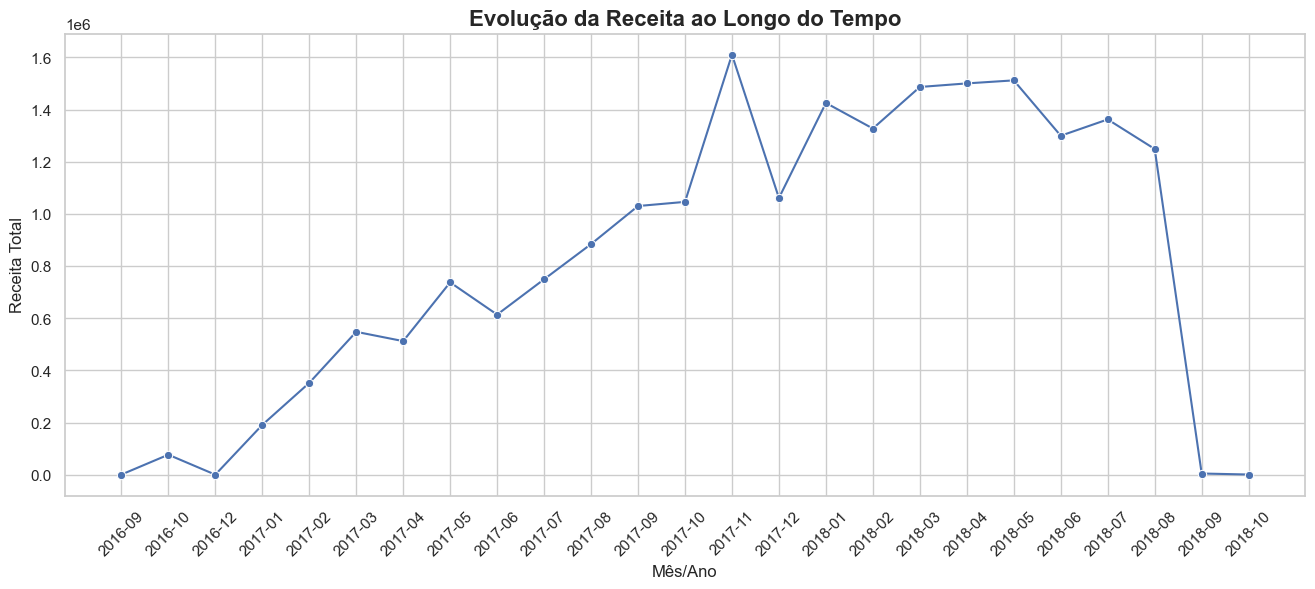

In [10]:
# =========================================================
# EVOLUÇÃO DA RECEITA AO LONGO DO TEMPO
# =========================================================

# Agrupando vendas por mês
vendas_mes = (
    df.groupby('mes_ano')['payment_value']
    .sum()
    .reset_index()
)

# Criando gráfico
plt.figure(figsize=(16,6))

sns.lineplot(
    data=vendas_mes,
    x='mes_ano',
    y='payment_value',
    marker='o'
)

# Ajustes visuais
plt.xticks(rotation=45)

plt.title(
    'Evolução da Receita ao Longo do Tempo',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Mês/Ano')

plt.ylabel('Receita Total')

plt.show()

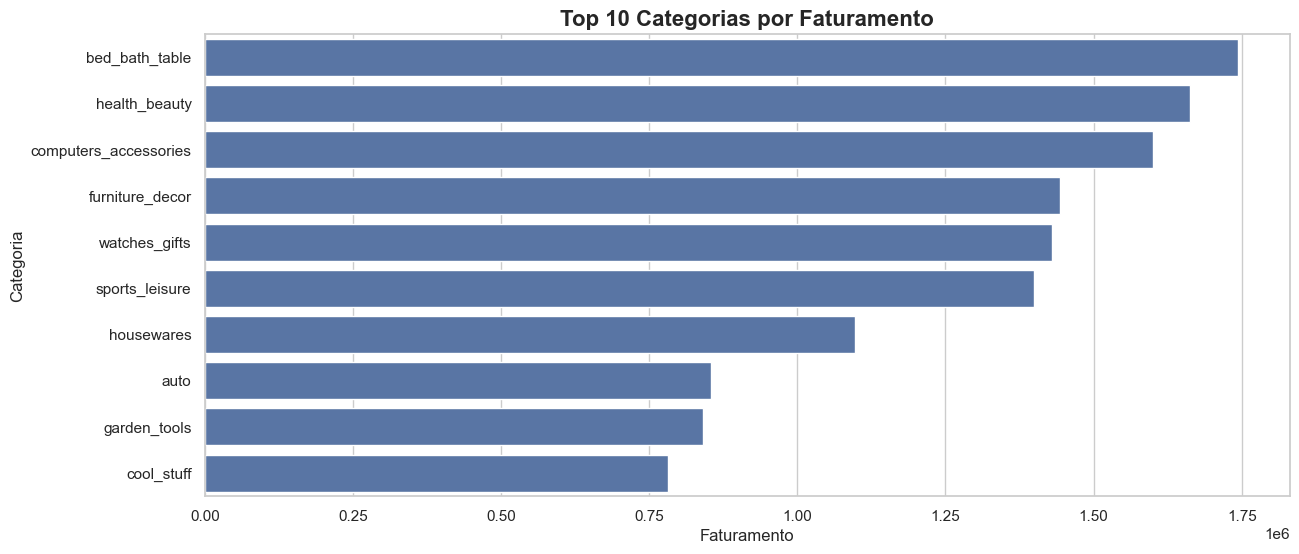

In [11]:
# =========================================================
# TOP 10 CATEGORIAS POR FATURAMENTO
# =========================================================

# Agrupando categorias
top_categorias = (
    df.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Criando gráfico
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_categorias,
    x='payment_value',
    y='product_category_name_english'
)

# Ajustes visuais
plt.title(
    'Top 10 Categorias por Faturamento',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Faturamento')

plt.ylabel('Categoria')

plt.show()

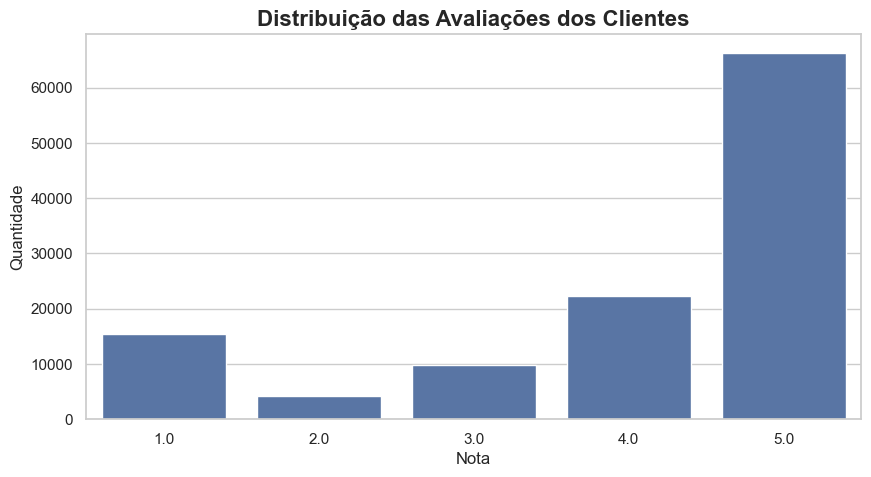

In [12]:
# =========================================================
# DISTRIBUIÇÃO DAS AVALIAÇÕES DOS CLIENTES
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='review_score'
)

plt.title(
    'Distribuição das Avaliações dos Clientes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Nota')

plt.ylabel('Quantidade')

plt.show()

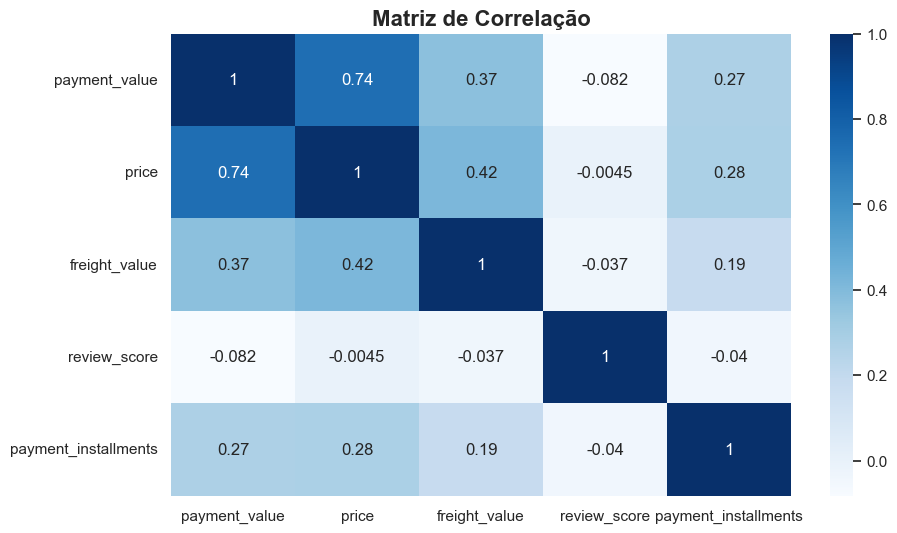

In [13]:
# =========================================================
# MATRIZ DE CORRELAÇÃO
# =========================================================

# Selecionando colunas numéricas
correlation = df[
    [
        'payment_value',
        'price',
        'freight_value',
        'review_score',
        'payment_installments'
    ]
].corr()

# Criando gráfico
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title(
    'Matriz de Correlação',
    fontsize=16,
    fontweight='bold'
)

plt.show()

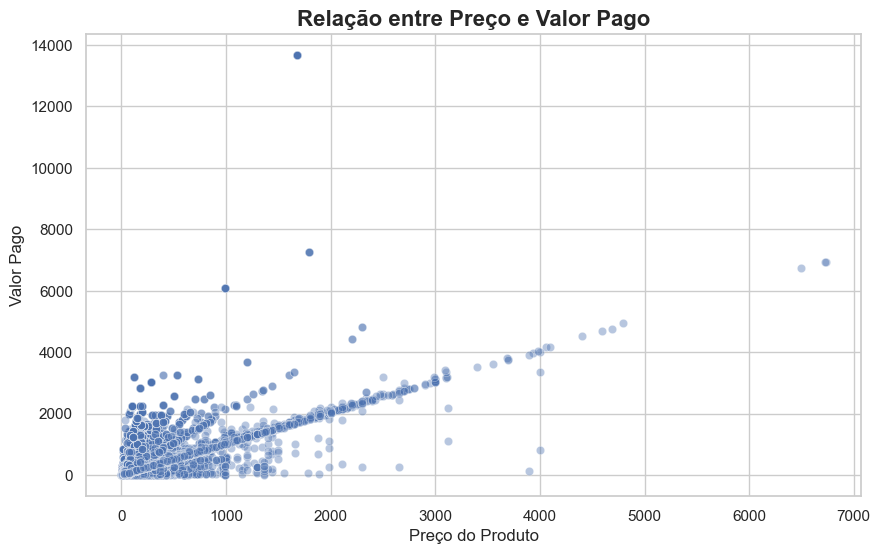

In [14]:
# =========================================================
# RELAÇÃO ENTRE PREÇO E VALOR PAGO
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='price',
    y='payment_value',
    alpha=0.4
)

plt.title(
    'Relação entre Preço e Valor Pago',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Preço do Produto')

plt.ylabel('Valor Pago')

plt.show()

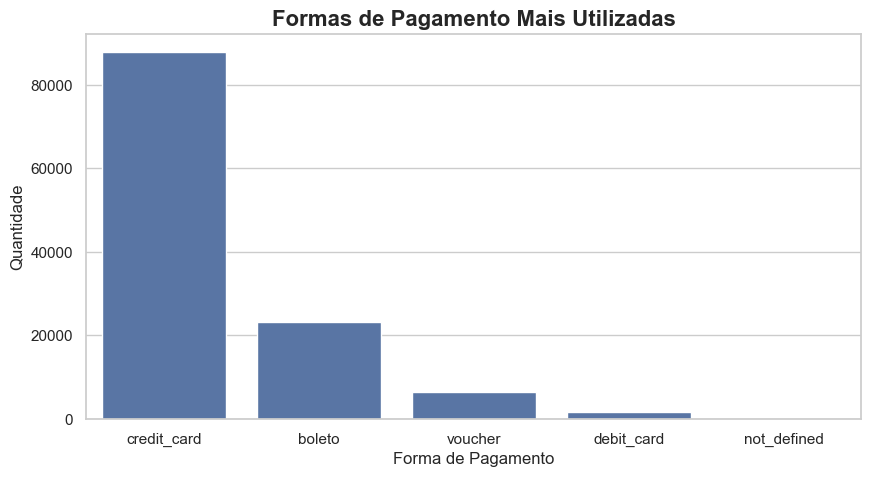

In [15]:
# =========================================================
# FORMAS DE PAGAMENTO MAIS UTILIZADAS
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='payment_type',
    order=df['payment_type'].value_counts().index
)

plt.title(
    'Formas de Pagamento Mais Utilizadas',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Forma de Pagamento')

plt.ylabel('Quantidade')

plt.show()

In [16]:
# =========================================================
# CONCLUSÕES E INSIGHTS
# =========================================================

print("""
CONCLUSÕES DO PROJETO

1. O e-commerce apresentou crescimento consistente
ao longo do período analisado, com destaque para
os meses de maior faturamento próximos ao período
da Black Friday.

2. As categorias mais lucrativas foram relacionadas
a casa, decoração, beleza e tecnologia, indicando
forte demanda desses segmentos.

3. A maioria dos clientes apresentou avaliações
positivas, com predominância de notas 5, sugerindo
boa experiência de compra.

4. O cartão de crédito foi o principal meio de
pagamento utilizado pelos consumidores.

5. A análise de correlação mostrou forte relação
entre preço dos produtos e valor pago, além de
evidenciar padrões importantes de comportamento
dos consumidores.

6. O projeto demonstrou como técnicas de análise
e visualização de dados podem auxiliar empresas
na tomada de decisões estratégicas.
""")


CONCLUSÕES DO PROJETO

1. O e-commerce apresentou crescimento consistente
ao longo do período analisado, com destaque para
os meses de maior faturamento próximos ao período
da Black Friday.

2. As categorias mais lucrativas foram relacionadas
a casa, decoração, beleza e tecnologia, indicando
forte demanda desses segmentos.

3. A maioria dos clientes apresentou avaliações
positivas, com predominância de notas 5, sugerindo
boa experiência de compra.

4. O cartão de crédito foi o principal meio de
pagamento utilizado pelos consumidores.

5. A análise de correlação mostrou forte relação
entre preço dos produtos e valor pago, além de
evidenciar padrões importantes de comportamento
dos consumidores.

6. O projeto demonstrou como técnicas de análise
e visualização de dados podem auxiliar empresas
na tomada de decisões estratégicas.



# 📊 Análise Estratégica de Vendas no E-commerce Brasileiro

## Projeto de Visualização da Informação

### Autor: Matheus Liberalino Nóbrega

Este projeto tem como objetivo analisar dados reais de um marketplace brasileiro utilizando Python para integração, tratamento e visualização de dados.

A análise busca identificar padrões de faturamento, comportamento de clientes, categorias mais relevantes e tendências temporais no e-commerce.

# 🎯 Objetivos do Projeto

- Realizar integração de múltiplos datasets
- Aplicar técnicas de tratamento de dados
- Construir indicadores estratégicos (KPIs)
- Desenvolver visualizações analíticas
- Identificar padrões de comportamento dos consumidores
- Gerar insights para tomada de decisão

# 🗂️ Sobre o Dataset

O dataset utilizado foi o Brazilian E-Commerce Public Dataset by Olist, disponível publicamente no Kaggle.

O conjunto contém informações reais de pedidos, pagamentos, produtos, avaliações e clientes de um marketplace brasileiro.

Dataset:
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

# 📌 Indicadores Estratégicos (KPIs)

Nesta etapa foram calculados indicadores fundamentais para análise de desempenho do e-commerce, incluindo:

- Receita total
- Quantidade de pedidos
- Ticket médio
- Avaliação média dos clientes

# 📈 Evolução da Receita ao Longo do Tempo

O gráfico abaixo apresenta a evolução do faturamento mensal do e-commerce ao longo do período analisado.

A análise temporal permite identificar tendências de crescimento, sazonalidade e períodos de maior faturamento.

# 🛒 Categorias Mais Lucrativas

Nesta análise são apresentadas as categorias que geraram maior faturamento para o marketplace.

Esse tipo de análise é importante para estratégias comerciais, marketing e gestão de estoque.

# ⭐ Avaliações dos Clientes

A distribuição das avaliações permite compreender o nível de satisfação dos consumidores em relação às compras realizadas no marketplace.

# 🔍 Matriz de Correlação

A matriz de correlação permite identificar relações entre variáveis numéricas do dataset, auxiliando na descoberta de padrões e comportamentos relevantes.

# ✅ Conclusão Final

A análise demonstrou o potencial das técnicas de visualização e exploração de dados para geração de insights estratégicos.

Foi possível identificar crescimento do faturamento, categorias mais relevantes, comportamento dos consumidores e padrões financeiros dentro do e-commerce analisado.

O projeto também evidenciou a importância da integração, tratamento e interpretação de dados para apoio à tomada de decisões empresariais.